In [1]:
import time
import torch.nn as nn
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchsummary import summary
import numpy as np
from torch.cuda.amp import autocast,GradScaler

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomResizedCrop(224,scale = (0.8,1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),(0.229, 0.224, 0.225))
])

In [3]:
device = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
display_image = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/train',transform = transforms.ToTensor())

In [5]:
train_data = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/train',transform = train_transform)
test_data = datasets.ImageFolder(root = 'Deep learning Data/New Plant Diseases Dataset(Augmented)/valid',transform = test_transform)

In [6]:
images,label = train_data[0]
print(images.shape)

torch.Size([3, 224, 224])


In [7]:
len(train_data.classes)

38

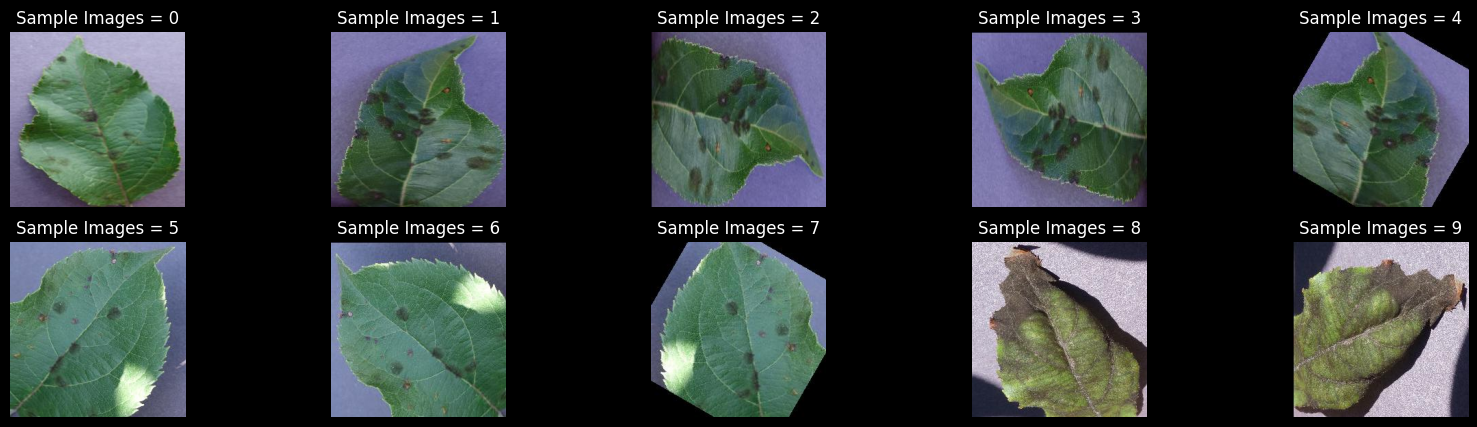

In [8]:
fig,axes = plt.subplots(2,5,figsize=(20,5))
for i,ax in enumerate(axes.flat):
    image,label = display_image[i]
    ax.imshow(image.permute(1,2,0))
    ax.axis('off')
    ax.set_title(f'Sample Images = {i}')
plt.show()

In [9]:
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True,drop_last = True,num_workers = 4,pin_memory=True)
test_loader = DataLoader(test_data, batch_size = 64,num_workers = 4,pin_memory=True)

In [11]:
class PlantDiseaseClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,kernel_size = 3,stride = 1,padding = 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,64,kernel_size = 3,stride = 1,padding = 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64,128,kernel_size = 3,stride = 1,padding = 1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128,256,kernel_size = 3,stride = 1,padding = 1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256,512,kernel_size = 3,stride = 1,padding = 1)
        self.bn5 = nn.BatchNorm2d(512)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512,38)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x,2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x,2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x,2)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool2d(x,2)
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.max_pool2d(x,2)
        x = self.gap(x)
        x = x.view(x.size(0),-1)
        x = self.dropout(x)
        x = self.fc2(x)
        return x



In [12]:
model = PlantDiseaseClassifier()
summary(model,(3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 224, 224]        896
├─BatchNorm2d: 1-2                       [-1, 32, 224, 224]        64
├─Conv2d: 1-3                            [-1, 64, 112, 112]        18,496
├─BatchNorm2d: 1-4                       [-1, 64, 112, 112]        128
├─Conv2d: 1-5                            [-1, 128, 56, 56]         73,856
├─BatchNorm2d: 1-6                       [-1, 128, 56, 56]         256
├─Conv2d: 1-7                            [-1, 256, 28, 28]         295,168
├─BatchNorm2d: 1-8                       [-1, 256, 28, 28]         512
├─Conv2d: 1-9                            [-1, 512, 14, 14]         1,180,160
├─BatchNorm2d: 1-10                      [-1, 512, 14, 14]         1,024
├─AdaptiveAvgPool2d: 1-11                [-1, 512, 1, 1]           --
├─Dropout: 1-12                          [-1, 512]                 --
├─Linear: 1-13                           [-1, 38]         

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 224, 224]        896
├─BatchNorm2d: 1-2                       [-1, 32, 224, 224]        64
├─Conv2d: 1-3                            [-1, 64, 112, 112]        18,496
├─BatchNorm2d: 1-4                       [-1, 64, 112, 112]        128
├─Conv2d: 1-5                            [-1, 128, 56, 56]         73,856
├─BatchNorm2d: 1-6                       [-1, 128, 56, 56]         256
├─Conv2d: 1-7                            [-1, 256, 28, 28]         295,168
├─BatchNorm2d: 1-8                       [-1, 256, 28, 28]         512
├─Conv2d: 1-9                            [-1, 512, 14, 14]         1,180,160
├─BatchNorm2d: 1-10                      [-1, 512, 14, 14]         1,024
├─AdaptiveAvgPool2d: 1-11                [-1, 512, 1, 1]           --
├─Dropout: 1-12                          [-1, 512]                 --
├─Linear: 1-13                           [-1, 38]         

In [13]:
epochs = 10
losses = torch.zeros(epochs)
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)
model.to(device)
trainAcc = []
testAcc = []
scaler = GradScaler()
for epoch in range(epochs):
    start_time = time.time()
    batchAcc = []
    batchLoss = []
    model.train()
    for X,y in train_loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        with autocast():
            ypred = model(X)
            loss = lossfun(ypred, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        batchLoss.append(loss.item())
        acc = 100*(torch.argmax(ypred,dim=1)==y).float().mean().item()
        batchAcc.append(acc)
    end_time = time.time()
    epoch_time = end_time - start_time
    trainAcc.append(np.mean(batchAcc))
    losses[epoch] = np.mean(batchLoss)
    model.eval()
    test_batchAcc = []
    with torch.no_grad():
        for X,y in test_loader:
            X = X.to(device)
            y = y.to(device)
            ypred = model(X)
            acc2 = 100*(torch.argmax(ypred,1)==y).float().mean().item()
            test_batchAcc.append(acc2)
    testAcc.append(np.mean(test_batchAcc))
    if (epoch % 5) == 0:
        print(f'epoch : {epoch},loss {losses[epoch]},time {epoch_time}')

C:\Users\amsha\AppData\Local\Temp\ipykernel_10868\226061768.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\amsha\AppData\Local\Temp\ipykernel_10868\226061768.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch : 0,loss 0.9118407964706421,time 145.29216504096985
epoch : 5,loss 0.1167665496468544,time 141.6511528491974


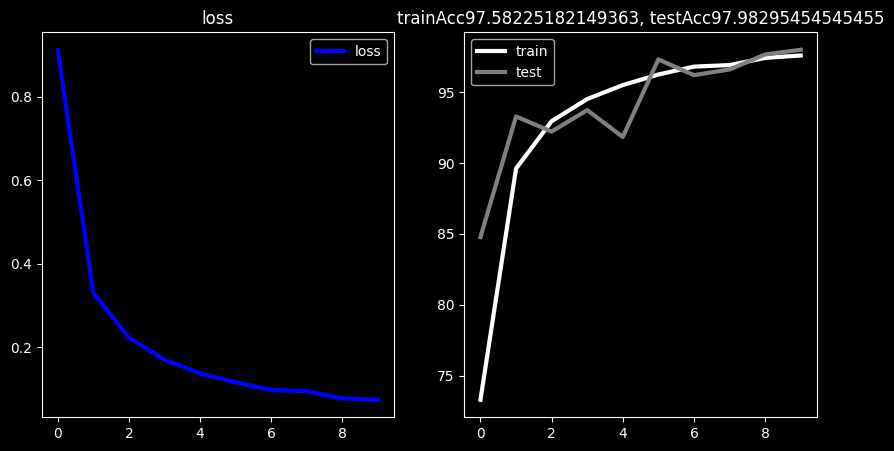

In [15]:
fig,ax = plt.subplots(1,2,figsize = (10,5))
ax[0].plot(losses,label = 'loss',lw = 3,color = 'blue')
ax[0].set_title('loss')
ax[0].legend()
ax[1].plot(trainAcc,label = 'train',lw = 3,color = 'white')
ax[1].plot(testAcc,label = 'test',lw = 3,color = 'gray')
ax[1].set_title(f'trainAcc{trainAcc[-1]}, testAcc{testAcc[-1]}')
ax[1].legend()
plt.show()